# Working with planetary constants

`planetarypy.constants` is a one-stop source for solar-system work, layering
three reference sets in a single namespace:

1. **Fundamental physics constants** (`G`, `c`, `h`, `k_B`, `M_sun`,
   `R_earth`, ...) — thin re-exports of `astropy.constants` so you don't
   manage two imports. CODATA-versioned, authoritative.
2. **NAIF SPICE PCK kernels** — cartographic (triaxial radii, flattening),
   orientation (pole RA/Dec, prime meridian, rotation rate), and **GM**
   for ~145 bodies, versioned by IAU report edition (2009 and 2015).
3. **NSSDC Planetary Fact Sheets** — "textbook parameters" (bond
   albedo, surface pressure, scale height, satellite count, orbital
   elements). NSSDC is NASA's National Space Science Data Center at
   Goddard Space Flight Center; D. R. Williams has maintained the
   per-body fact sheets there since 1996. Drawn from a longitudinal
   archive of 913 captures spanning 1996–2025 (Zenodo:
   [10.5281/zenodo.20122987](https://doi.org/10.5281/zenodo.20122987)).

Per-body fields come back as a `Constant` (an [`astropy.units.Quantity`](https://docs.astropy.org/en/stable/api/astropy.units.Quantity.html)
subclass) carrying full provenance — which kernel or NSSDC capture
supplied it. The default surface merges PCK and NSSDC transparently: PCK
wins for cartographic fields when both have data; NSSDC fills in
everything PCK doesn't carry.

## Fundamental physics constants are right there

No separate `astropy.constants` import needed:

In [1]:
from planetarypy.constants import G, c, k_B, M_sun, R_earth

G

<<class 'astropy.constants.codata2018.CODATA2018'> name='Gravitational constant' value=6.6743e-11 uncertainty=1.5e-15 unit='m3 / (kg s2)' reference='CODATA 2018'>

In [2]:
# Compose freely with per-body fields
from planetarypy.constants import Mars

(Mars.GM / G).to('kg')   # Mars mass derived from GM and G

<Constant Mars.GM = 6.41691e+23 kg  (IAU 2015)>

## Quick start: everyday access

Import a body, access its fields:

In [3]:
from planetarypy.constants import Mars

Mars.GM                          # gravitational parameter

<Constant Mars.GM = 42828.4 km3 / s2  (IAU 2015)>

In [4]:
Mars.radii                       # triaxial (a, b, c)

<Constant Mars.radii = [3396.19, 3396.19, 3376.2 ] km  (IAU 2015)>

In [5]:
Mars.bond_albedo                 # NSSDC-sourced

<Constant Mars.bond_albedo = 0.25   (NSSDC marsfact.html updated 2025-05-19)>

In [6]:
Mars.semimajor_axis              # NSSDC-sourced

<Constant Mars.semimajor_axis = 2.27956e+08 km  (NSSDC marsfact.html updated 2025-05-19)>

## Provenance: every value tells you where it came from

A `Constant` is an [`astropy.units.Quantity`](https://docs.astropy.org/en/stable/api/astropy.units.Quantity.html) plus metadata. The `source`,
`reference`, and `description` attributes identify the origin so a paper
citing a particular Mars GM can always be traced back to the exact kernel
or NSSDC capture used.

In [7]:
Mars.GM.source             # which kernel

'pck00011.tpc'

In [8]:
Mars.GM.reference          # citation

"IAU 2015 — Archinal et al., 'Report of the IAU Working Group on Cartographic Coordinates and Rotational Elements: 2015', Celest. Mech. Dyn. Astr. (2018)"

In [9]:
Mars.GM.description

'Gravitational parameter'

In [10]:
# A field sourced from NSSDC instead of PCK
Mars.bond_albedo.source

'NSSDC marsfact.html updated 2025-05-19'

## Discovery helpers

The registry exposes lookup by NAIF id and case-insensitive name, plus
helpers grouped by physical class.

In [11]:
from planetarypy.constants import (
    planets, moons, asteroids, comets,
    dwarf_planets, mission_visited, find_body,
)

[b.name for b in planets()]

['MERCURY',
 'VENUS',
 'EARTH',
 'MARS',
 'JUPITER',
 'SATURN',
 'URANUS',
 'NEPTUNE',
 'PLUTO']

In [12]:
[m.name for m in moons(of='Saturn')][:8]

['MIMAS',
 'ENCELADUS',
 'TETHYS',
 'DIONE',
 'RHEA',
 'TITAN',
 'HYPERION',
 'IAPETUS']

In [13]:
# Asteroids and comets visited by spacecraft
[b.name for b in mission_visited()]

['BORRELLY',
 'CHURYUMOV-GERASIMENKO',
 'HALLEY',
 'TEMPEL 1',
 'WILD 2',
 'CERES',
 'VESTA',
 'LUTETIA',
 'MATHILDE',
 'EROS',
 'STEINS',
 'ITOKAWA',
 'BENNU']

In [14]:
find_body('Bennu')          # case-insensitive name
# or by NAIF id: find_body(606)

<Body BENNU (NAIF 2101955, class='asteroid')>

## Reproducing an older paper's calculation

`Body.at_time(date)` returns a snapshot using whichever PCK edition was
current on that date — no need to know submodule names. IAU 2009 PCK
was published 2010-10-21; IAU 2015 PCK was published 2018-09-20.

In [15]:
# Mars pole declination, as a 2012 paper would have seen it
mars_2012 = Mars.at_time('2012')
mars_2024 = Mars.at_time('2024')
print(f"2012 (IAU 2009): pole_dec = {mars_2012.pole_dec}")
print(f"2024 (IAU 2015): pole_dec = {mars_2024.pole_dec}")
print(f"Δ over edition jump: {mars_2024.pole_dec - mars_2012.pole_dec}")
print()
print(f"Sources:")
print(f"  2012: {mars_2012.pole_dec.source}")
print(f"  2024: {mars_2024.pole_dec.source}")

2012 (IAU 2009): pole_dec = 52.8865 deg
2024 (IAU 2015): pole_dec = 54.432516 deg
Δ over edition jump: 1.5460160000000016 deg

Sources:
  2012: pck00010.tpc
  2024: pck00011.tpc


## Time-travel

`Body.at_time(date)` returns a snapshot of the body with all fields
resolved as of that date. It walks both the PCK editions and the NSSDC
capture history per field, returning the most recent value that was
current on or before the requested date.

`date` accepts `"2001"`, `"2001-06"`, or `"2001-06-15"`. Year-only and
year-month resolve to the *end* of that period, so "what was current in
2001" picks the latest 2001 capture rather than the first.

In [16]:
# Mars bond albedo: 0.16 in the early NSSDC pages, 0.25 today
Mars.at_time('1998').bond_albedo, Mars.at_time('2024').bond_albedo

(<Constant Mars.bond_albedo = 0.16   (NSSDC marsfact.html updated 1998-11-27)>,
 <Constant Mars.bond_albedo = 0.25   (NSSDC marsfact.html updated 2024-10-03)>)

In [17]:
# Function form — same lookup, single-field access
from planetarypy.constants import at_time
at_time('mars', 'bond_albedo', '1998')

<Constant Mars.bond_albedo = 0.16   (NSSDC marsfact.html updated 1998-11-27)>

In [18]:
# Saturn's satellite count over three decades —
# tells the story of moon discoveries
from planetarypy.constants import Saturn
for date in ['2000', '2005', '2010', '2015', '2020', '2024']:
    n = int(Saturn.at_time(date).number_of_satellites.value)
    print(f'{date}: {n} satellites')

2000: 22 satellites
2005: 47 satellites
2010: 62 satellites
2015: 62 satellites
2020: 82 satellites
2024: 146 satellites


### PCK validity gating

PCK kernels have their own publication date — the IAU 2009 PCK was
released 2010-10-21. For dates *before* that, `at_time` falls back to
NSSDC even for fields PCK normally wins. So a query for "what was Mars's
GM in 2008?" returns NSSDC's GM (the only published value at that date),
while "what was Mars's GM in 2024?" returns the PCK value.

In [19]:
Mars.at_time('2008').GM.source   # NSSDC, pre-PCK

'NSSDC marsfact.html updated 2007-11-29'

In [20]:
Mars.at_time('2024').GM.source   # PCK

'pck00011.tpc'

## The NSSDC-explicit namespace

The default `Mars.GM` returns the PCK value. If you specifically want
NSSDC's GM (which may differ slightly — different solutions), reach
through the `nssdc` submodule. Same shape as the IAU-edition submodules.

In [21]:
from planetarypy.constants import nssdc

# NSSDC's own GM for Jupiter, vs default (PCK)
from planetarypy.constants import Jupiter
Jupiter.GM, nssdc.Jupiter.GM

(<Constant Jupiter.GM = 1.26687e+08 km3 / s2  (IAU 2015)>,
 <Constant Jupiter.GM = 1.26687e+08 km3 / s2  (NSSDC jupiterfact.html updated 2024-10-02)>)

In [22]:
# Full timeline of a single (body, field) — every NSSDC revision
hist = nssdc.history('saturn', 'number_of_satellites')
for date, val, url in hist[::5]:    # every 5th entry
    print(f'{date}: {int(val.value)}')

2000-11-13: 22
2002-10-15: 30
2004-09-01: 33
2010-08-09: 62
2014-04-25: 62
2015-12-22: 62
2016-02-29: 62
2016-05-19: 62
2016-12-23: 62
2018-09-27: 62
2021-12-16: 82
2024-10-03: 146


Pair `nssdc.history()` with matplotlib for a quick drift plot — here's
Saturn's known moon count climbing from 18 to 274 across three decades:

Text(0, 0.5, 'Known moons')

Text(0.5, 1.0, "Saturn's satellite count — NSSDC revisions, 1996–2025")

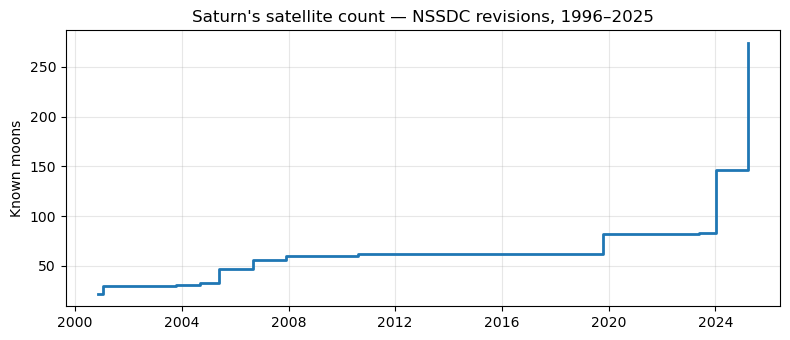

In [23]:
import matplotlib.pyplot as plt
from datetime import date

hist = nssdc.history('saturn', 'number_of_satellites')
dates = [date.fromisoformat(d) for d, _, _ in hist]
counts = [int(v.value) for _, v, _ in hist]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.step(dates, counts, where='post', linewidth=2)
ax.set_ylabel('Known moons')
ax.set_title("Saturn's satellite count — NSSDC revisions, 1996–2025")
ax.grid(True, alpha=0.3)
fig.tight_layout()

## When to use what

| Use case                                       | Surface                    |
|------------------------------------------------|----------------------------|
| Everyday "give me Mars's mass"                 | `from planetarypy.constants import Mars`             |
| "What was the value at the time?" (paper reproducibility) | `Mars.at_time('2012').pole_dec`               |
| Drift / science-history study                  | `nssdc.history(body, field)`                         |
| Deliberately citing NSSDC over PCK             | `from planetarypy.constants.nssdc import Mars`       |
| Fundamental physics constants (G, c, M_sun, …) | `from planetarypy.constants import G, c, M_sun`      |

## Further reading

- Design rationale: [Constants design](../explanation/constants_design.qmd)
- NSSDC longitudinal archive: [10.5281/zenodo.20122987](https://doi.org/10.5281/zenodo.20122987)
- NAIF PCK file documentation: [SPICE Required Reading](https://naif.jpl.nasa.gov/pub/naif/toolkit_docs/C/req/pck.html)